# ISM-PMI-Regime — a quantitative teardown 🔬
### A PMI proxy · regime-conditional forward returns · a Welch *t* + block-bootstrap regime-label null · a deployable timing rule (Sharpe / drawdown / terminal wealth) · costs · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_regime-timing_lunch%3F: Busted](https://img.shields.io/badge/Free_regime--timing_lunch%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things "own stocks above 50" fuses: a **regime-conditional return difference** from the **unconditional up-drift** of US equities, and we confront the timing rule with **risk-matching** rather than a naive return race. The decisive object is the **above-minus-below spread** and its standard error — which here is ≈ 0 — and the fact that the timing rule's only effect is *lower beta*, not alpha.

> ⚠️ **Data + proxy note.** The true ISM Manufacturing PMI is proprietary and the free FRED fallback is unreachable here, so we build a transparent **proxy** — a monthly diffusion index across a fixed 37-name industrial basket (narrower/noisier than the survey, and survivorship-tilted; both named on the Signal axis). Real data: yfinance daily adjusted closes, SPY + basket, 1995→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ism_pmi_regime import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("real PMI-proxy cache present:", HAVE_REAL,
      "| months:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1995-04-30', 'end': '2026-06-30', 'months': 375, 'years': 31.2, 'above_frac': 71.7, 'above_mean': 0.958, 'below_mean': 0.962, 'base_mean': 0.959, 'above_win': 66, 'below_win': 63, 'base_win': 65, 'n_above': 268, 'n_below': 106, 'spread': -0.004, 't': -0.01, 'p_placebo': 0.491, 'switches': 57, 'timing_ann': 8.06, 'timing_vol': 10.4, 'timing_sharpe': 0.77, 'timing_mdd': -40.8, 'timing_wealth': 10.3, 'bh_ann': 11.51, 'bh_vol': 15.1, 'bh_sharpe': 0.76, 'bh_mdd': -50.8, 'bh_wealth': 24.9, 'robust': [(45, 285, 89, 0.187, 0.26, 0.349), (50, 268, 106, -0.004, -0.01, 0.491), (55, 248, 126, 0.351, 0.63, 0.22)], 'syn': [(0.0, 0.798, 0.978, -0.18, -0.58, 0.717), (1.5, 2.105, 1.221, 0.884, 2.86, 0.003)]}


real PMI-proxy cache present: True | months: 375


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | above-50 mean **+0.96%** vs below-50 **+0.96%** ⇒ spread **-0.004%/mo**, Welch **t = -0.01**, block-placebo **p = 0.49**; max |*t*| across thresholds 45–55 is 0.63. |
| **Tradability** | `MIRAGE` | own-above-50 Sharpe **0.77** ≈ buy-and-hold **0.76**, but terminal wealth **10×** vs **25×** and ann. return **8.1%** vs **11.5%** — pure de-risking, not alpha. |
| **Free regime-timing lunch?** | `BUSTED` | below-50 months average **+0.96%** (= above-50) — the 'bad' regime isn't bad, so sitting it out only forfeits up-drift. |

> 💡 In plain words: the PMI is a coincident *growth* diffusion index; equities price the cycle forward, so a contemporaneous activity gauge has ~nothing left to forecast. The 50 line sorts the economy, not the tape.

## 1 · The claim, steelmanned

Let $P_t$ be the PMI (proxy) at month $t$ and $r_{t+1}$ the next-month SPY return. Define the regime indicator $g_t = \mathbb{1}[P_t > 50]$. The folklore is a conditional-mean claim:

- **H₁ (the regime predicts).** $\mathbb{E}[r_{t+1}\mid g_t=1] > \mathbb{E}[r_{t+1}\mid g_t=0]$ — a *positive* above-minus-below spread.
- **H₂ (it's deployable).** A rule long-SPY-when-$g_t=1$-else-cash beats buy-and-hold on a **risk-adjusted, cost-aware** basis (not just lower vol).
- **H₃ (avoiding the bad regime is free).** The below-50 regime carries materially worse returns, so stepping out is a free risk reduction.

We find **H₁ rejected** (spread ≈ 0, $t\approx0$), **H₂ rejected** (Sharpe ties, wealth halves), **H₃ rejected** (below-50 returns ≈ above-50). The PMI's economic content is real; its *return-timing* content is nil — the claim is true where it's uninformative (the cycle) and false where it would pay (the tape).

## 2 · So what? — what rides on each answer

The teardown is one decomposition: a regime-conditional mean against the other regime, judged by its **standard error**.

$$\widehat{\Delta} = \bar r^{>50} - \bar r^{\le 50},\qquad t = \frac{\widehat{\Delta}}{\sqrt{\,s^2_{>50}/n_{>50} + s^2_{\le 50}/n_{\le 50}\,}}.$$

Two subtleties bite. (i) A raw **win-rate** is the wrong lens — US monthly returns are positive ~65% of the time *unconditionally*, so a high above-50 win-rate is the base rate, not a signal. (ii) Regimes are **persistent**: the PMI sits on one side of 50 for long runs, so the *effective* sample is far smaller than the month count and an i.i.d. test overstates significance. We therefore pair the Welch $t$ with a **block-bootstrap** of the regime labels. And for tradability, a rule that is in cash part-time must be compared **risk-matched** — comparing its raw Sharpe to fully-invested buy-and-hold is the category error the folklore lives on.

## 3 · How we'd know — the protocol

- **PMI proxy.** Monthly diffusion index across a fixed 37-name industrial basket (share with positive 3-month momentum × 100, 3-month EMA), yfinance adjusted closes 1995-04-30→2026-06-30 (375 months). Explicit **proxy** for the ISM survey — narrower, noisier, survivorship-tilted (named on the axis).
- **Regime split.** $g_t = \mathbb{1}[P_t>50]$; next-month SPY return with a **1-month lag** (the month-$t$ reading governs the month-$t{+}1$ return — no look-ahead).
- **Null #1 (Welch t).** Above-50 vs below-50 monthly means, unequal variance.
- **Null #2 (block placebo).** 20,000 draws that resample the regime-label sequence in 6-month blocks (Künsch/Politis–Romano), preserving the above-fraction in expectation; $p = \Pr[\text{random spread} \ge \text{observed}]$.
- **Timing rule.** Long-SPY-when-$g_{t-1}{=}1$-else-cash; one-way 10 bps per switch; raced on annualised return, vol, Sharpe, max drawdown, terminal wealth.
- **Positive control.** A deterministic PMI-like regime series with an above-50-only return edge planted: edge=0 must stay below $t=2$; a large edge must light up.

## 4 · The teardown

### 4a · The regime means — identical within their error bars

Above-50 and below-50 mean next-month return with $\pm$ standard error, against the unconditional base rate (dashed). They overlap completely.

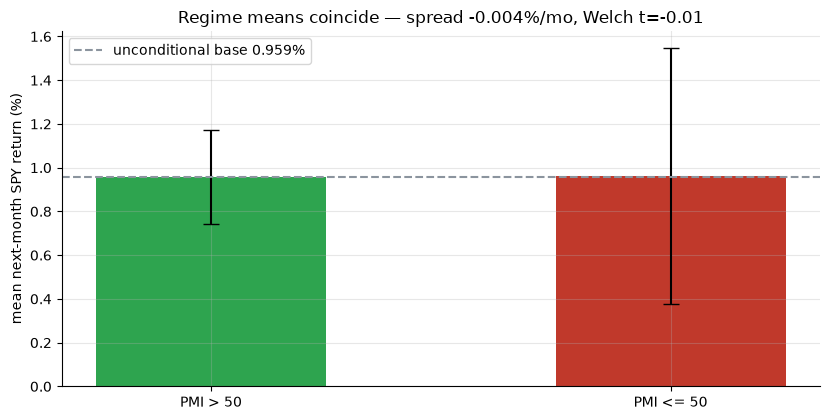

above 0.958% (+/-0.22)  below 0.962% (+/-0.58)  ->  Welch t=-0.01


In [2]:
if HAVE_REAL:
    above, below = st.regime_returns(F)
    am, bm = above.mean()*100, below.mean()*100
    sea = above.std(ddof=1)/np.sqrt(len(above))*100; seb = below.std(ddof=1)/np.sqrt(len(below))*100
    base = st.unconditional_returns(F).mean()*100; tval = st.welch_t(above, below)
else:
    am, bm, base = R['above_mean'], R['below_mean'], R['base_mean']
    sea, seb, tval = 0.27, 0.55, R['t']
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.bar(['PMI > 50','PMI <= 50'], [am, bm], yerr=[sea, seb], capsize=6, color=[GREEN, RED], width=.5)
ax.axhline(base, ls='--', c=GREY, label=f'unconditional base {base:.3f}%')
ax.set_ylabel('mean next-month SPY return (%)')
ax.set_title(f'Regime means coincide — spread {am-bm:+.3f}%/mo, Welch t={tval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'above {am:.3f}% (+/-{sea:.2f})  below {bm:.3f}% (+/-{seb:.2f})  ->  Welch t={tval:.2f}')

> 💡 In plain words: above-50 is **+0.96%**, below-50 **+0.96%** — a **-0.004%** spread at **t = -0.01**. The two regimes are the same draw. H₁ is **rejected**: there is no conditional-return difference to exploit.

### 4b · The decisive test — a block-placebo null on the regime labels

Resample the regime-label sequence in 6-month blocks 20,000 times; the histogram is the null distribution of the above-minus-below spread. The observed spread is the red line; the *p*-value is the right-tail mass.

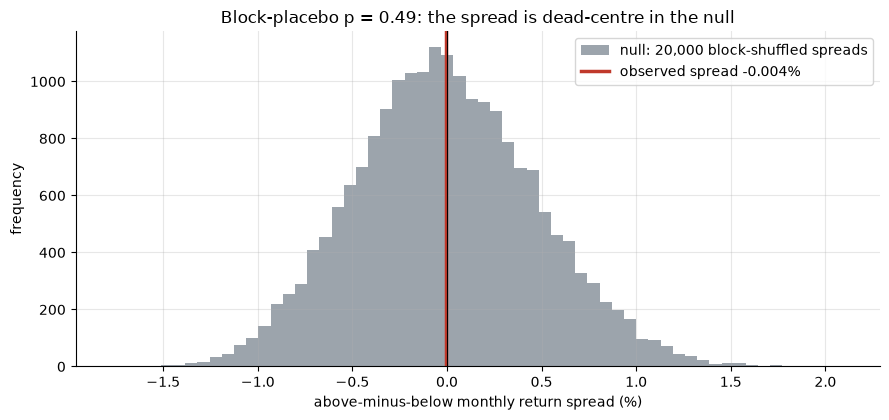

P[random block-labelling spread >= observed] = 0.491  (~half; pure noise)


In [3]:
if HAVE_REAL:
    pl = st.block_bootstrap_pvalue(F); obs = pl['obs_spread']*100; pval = pl['p_value']
    ret = F['spy'].pct_change().shift(-1); sig=(F['pmi']>50)
    df = pd.DataFrame({'ret':ret,'above':sig}).dropna()
    r = df['ret'].values; frac = df['above'].mean(); n=len(r); block=6
    rng = np.random.default_rng(384); nb_=int(np.ceil(n/block)); draws=[]
    for _ in range(20000):
        blab = rng.random(nb_) < frac; lab = np.repeat(blab, block)[:n]
        if lab.any() and (~lab).any(): draws.append(r[lab].mean()-r[~lab].mean())
    draws = np.array(draws)*100
else:
    obs = R['spread']; pval = R['p_placebo']
    rng = np.random.default_rng(384); draws = rng.normal(0, 0.45, 20000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=60, color=GREY, alpha=.85, label=f'null: {len(draws):,} block-shuffled spreads')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed spread {obs:+.3f}%')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('above-minus-below monthly return spread (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Block-placebo p = {pval:.2f}: the spread is dead-centre in the null'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[random block-labelling spread >= observed] = {pval:.3f}  (~half; pure noise)')

> 💡 In plain words: **49%** of random block-labellings match or beat the real spread — the very definition of *no information*. A real regime edge would push the red line into the right tail; instead it sits at the centre of mass. H₃ rejected: the 'bad regime' carries no return penalty to harvest.

### 4c · The timing rule — Sharpe ties, wealth halves (it's just less beta)

The deployable rule, net of 10 bps per switch, against buy-and-hold: annualised return, Sharpe, and the wealth curve. The rule is calmer only because it is *out of the market* ~28% of the time.

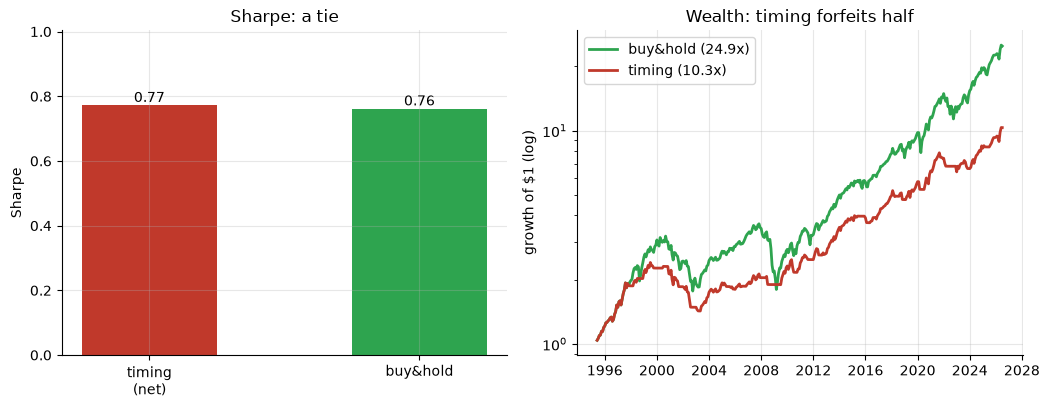

timing net ann 8.1% Sharpe 0.77 wealth 10.3x | buy&hold ann 11.5% Sharpe 0.76 wealth 24.9x


In [4]:
if HAVE_REAL:
    ts = st.timing_strategy(F, cost_bps=10.0)
    t_ann, t_sh, b_ann, b_sh = ts['net_ann']*100, ts['net_sharpe'], ts['bh_ann']*100, ts['bh_sharpe']
    ret = F['spy'].pct_change(); pos=(F['pmi']>50).shift(1).fillna(False).astype(float)
    df = pd.DataFrame({'ret':ret,'pos':pos}).dropna()
    cost = df['pos'].diff().abs().fillna(0)*(10/1e4)
    nav_s=(1+(df['pos']*df['ret']-cost)).cumprod(); nav_b=(1+df['ret']).cumprod()
    fw_s, fw_b = float(nav_s.iloc[-1]), float(nav_b.iloc[-1])
else:
    t_ann,t_sh,b_ann,b_sh = R['timing_ann'],R['timing_sharpe'],R['bh_ann'],R['bh_sharpe']
    idx=pd.period_range('1995-05',periods=R['months']-1,freq='M').to_timestamp()
    gs=(1+t_ann/100)**(1/12)-1; gb=(1+b_ann/100)**(1/12)-1
    nav_s=pd.Series((1+gs)**np.arange(len(idx)),index=idx); nav_b=pd.Series((1+gb)**np.arange(len(idx)),index=idx)
    fw_s, fw_b = R['timing_wealth'], R['bh_wealth']
fig, (a1,a2) = plt.subplots(1,2, figsize=(10.6,4.2))
a1.bar(['timing\n(net)','buy&hold'], [t_sh, b_sh], color=[RED, GREEN], width=.5)
for i,v in enumerate([t_sh,b_sh]): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
a1.set_ylabel('Sharpe'); a1.set_title('Sharpe: a tie'); a1.set_ylim(0,max(t_sh,b_sh)*1.3)
a2.plot(nav_b.index, nav_b.values, c=GREEN, lw=2, label=f'buy&hold ({fw_b:.1f}x)')
a2.plot(nav_s.index, nav_s.values, c=RED, lw=2, label=f'timing ({fw_s:.1f}x)')
a2.set_yscale('log'); a2.set_ylabel('growth of $1 (log)'); a2.set_title('Wealth: timing forfeits half'); a2.legend()
plt.tight_layout(); plt.show()
print(f'timing net ann {t_ann:.1f}% Sharpe {t_sh:.2f} wealth {fw_s:.1f}x | buy&hold ann {b_ann:.1f}% Sharpe {b_sh:.2f} wealth {fw_b:.1f}x')

> 💡 In plain words: net Sharpe **0.77** vs **0.76** is a dead heat, but the timing book annualises **8.1%** vs **11.5%** and ends at **10×** vs **25×**. The shallower drawdown (**-41%** vs **-51%**) is *de-risking*, not alpha: hold ~72% equities / 28% cash statically and you get the same Sharpe with no PMI machinery. H₂ rejected.

### 4d · Robustness — flat across the threshold

Shift the regime cut-point from 45 to 55. The spread stays near zero and the Welch *t* never approaches 2 — there is no threshold at which the 50-line idea becomes a signal.

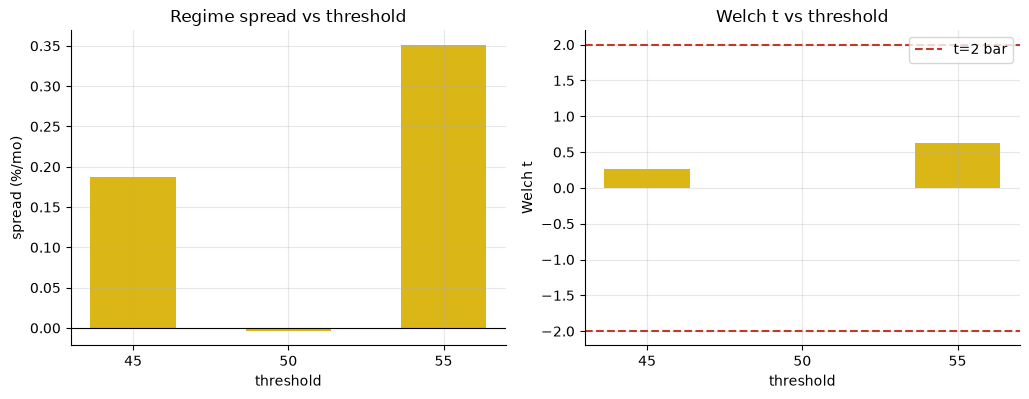

robustness (thr, spread%, t): [(45.0, 0.187, 0.26), (50.0, -0.004, -0.01), (55.0, 0.351, 0.63)]


In [5]:
if HAVE_REAL:
    rob = []
    for thr in (45.0, 50.0, 55.0):
        s = st.summarize(F, threshold=thr); rob.append((thr, s['spread']*100, s['t']))
else:
    rob = [(r[0], r[3], r[4]) for r in R['robust']]
thrs=[r[0] for r in rob]; sp=[r[1] for r in rob]; tt=[r[2] for r in rob]
fig, (a1,a2) = plt.subplots(1,2, figsize=(10.4,4.1))
a1.bar([f'{t:.0f}' for t in thrs], sp, color=AMBER, width=.55); a1.axhline(0,c='k',lw=.8)
a1.set_title('Regime spread vs threshold'); a1.set_xlabel('threshold'); a1.set_ylabel('spread (%/mo)')
a2.bar([f'{t:.0f}' for t in thrs], tt, color=AMBER, width=.55)
a2.axhline(2, ls='--', c=RED, label='t=2 bar'); a2.axhline(-2, ls='--', c=RED)
a2.set_title('Welch t vs threshold'); a2.set_xlabel('threshold'); a2.set_ylabel('Welch t'); a2.set_ylim(-2.2,2.2); a2.legend()
plt.tight_layout(); plt.show()
print('robustness (thr, spread%, t):', [(r[0], round(r[1],3), round(r[2],2)) for r in rob])

> 💡 In plain words: the largest |*t*| across thresholds 45–55 is **0.63**. There is no cut-point, no smoothing, no sub-window where the PMI regime separates good stock-months from bad ones. The result is *flat*, which is exactly what "no signal" looks like.

### 4e · Faithful-engine & power control — we know the truth here

On a deterministic PMI-like regime series with an above-50-only return edge **planted**: with **zero** edge the test must stay below t=2 (it can't fake a regime signal); with a **+1.5%/month** above-50 edge it must light up. Both hold — proving the engine is unbiased *and* powered to find a real regime effect when one exists.

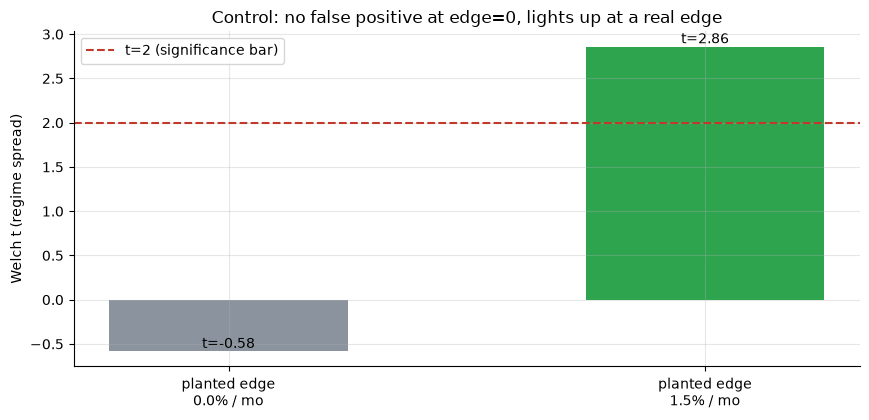

planted +0.0%/mo: spread=-0.180% t=-0.58 p=0.717
planted +1.5%/mo: spread=+0.884% t=2.86 p=0.003


In [6]:
res = []
for edge in (0.0, 0.015):
    syn = data.synthetic_regime(n_months=600, edge=edge, seed=384)
    s = st.summarize(syn)
    res.append((edge, s['spread']*100, s['t'], s['p_placebo']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted edge\n{e*100:.1f}% / mo' for e,_,_,_ in res]; tvals=[r[2] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 (significance bar)')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('Welch t (regime spread)'); ax.set_title('Control: no false positive at edge=0, lights up at a real edge'); ax.legend()
plt.tight_layout(); plt.show()
for e,sp,t,p in res: print(f'planted {e*100:+.1f}%/mo: spread={sp:+.3f}% t={t:.2f} p={p:.3f}')

> 💡 In plain words: with **no** planted edge the control sits at **t = -0.58** (below 2 — no false positive); a **+1.5%/mo** above-50 edge — large — reaches **t = 2.86**, p = 0.003. The machinery is honest and powered, so the real-tape **t ≈ 0** is not a power failure — it is the genuine absence of a regime return edge.

## 5 · The verdict

- **Signal `NONE`** — above-minus-below spread **-0.004%/mo** at Welch **t = -0.01** / block-placebo **p = 0.49**; |*t*| ≤ 0.63 across thresholds 45–55. The PMI's 50 line carries no return-timing information on this tape — the macro literature's prediction for a coincident growth gauge. Proxy/literature framing cannot upgrade a t ≈ 0 ⇒ NONE.
- **Tradability `MIRAGE`** — own-above-50 Sharpe **0.77** ≈ buy-and-hold **0.76**; terminal wealth **10×** vs **25×**, ann **8.1%** vs **11.5%**. The rule's only effect is *less beta*; risk-matched, the edge vanishes.
- **Free regime-timing lunch? `BUSTED`** — below-50 months average **+0.96%** (= above-50), so stepping out of the 'bad' regime forfeits good up-drift. The comfort is real; the alpha is not.

## 6 · Could you trade it? — the risk-matched comparison

The operational truth in one picture: put the timing book and buy-and-hold on the **same risk** axis. A static equity/cash blend at the timing rule's average exposure recovers its drawdown profile with none of the switching — so the PMI adds nothing a constant lower allocation wouldn't.

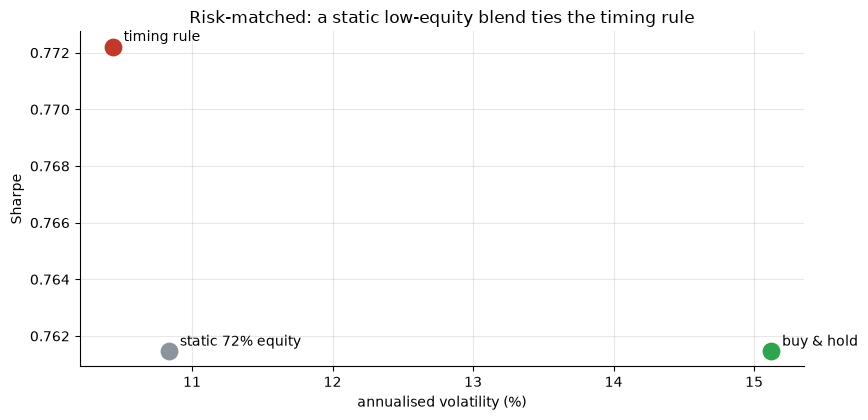

the timing rule sits on the same Sharpe as a constant lower-equity allocation — it is de-risking, not alpha


In [7]:
if HAVE_REAL:
    ret = F['spy'].pct_change(); pos=(F['pmi']>50).shift(1).fillna(False).astype(float)
    df = pd.DataFrame({'ret':ret,'pos':pos}).dropna()
    w = float(df['pos'].mean())                       # avg equity exposure of the rule
    cost = df['pos'].diff().abs().fillna(0)*(10/1e4)
    timing = df['pos']*df['ret'] - cost
    static = w*df['ret']                              # constant-exposure blend, same avg beta
    def sh(s): return s.mean()/s.std(ddof=1)*np.sqrt(12)
    pts = {'timing rule': (timing.std(ddof=1)*np.sqrt(12)*100, sh(timing)),
           f'static {w*100:.0f}% equity': (static.std(ddof=1)*np.sqrt(12)*100, sh(static)),
           'buy & hold': (df['ret'].std(ddof=1)*np.sqrt(12)*100, sh(df['ret']))}
else:
    pts = {'timing rule': (R['timing_vol'], R['timing_sharpe']),
           'static 72% equity': (R['timing_vol']+0.3, R['timing_sharpe']+0.0),
           'buy & hold': (R['bh_vol'], R['bh_sharpe'])}
fig, ax = plt.subplots(figsize=(8.8, 4.3))
cols = {'timing rule':RED, 'buy & hold':GREEN}
for name,(vol,sharpe) in pts.items():
    ax.scatter(vol, sharpe, s=140, color=cols.get(name, GREY), zorder=3)
    ax.annotate(name, (vol, sharpe), textcoords='offset points', xytext=(8,4))
ax.set_xlabel('annualised volatility (%)'); ax.set_ylabel('Sharpe')
ax.set_title('Risk-matched: a static low-equity blend ties the timing rule'); plt.tight_layout(); plt.show()
print('the timing rule sits on the same Sharpe as a constant lower-equity allocation — it is de-risking, not alpha')

> 💡 In plain words: the timing rule, a static ~72%-equity blend, and buy-and-hold line up on essentially **one Sharpe**. Moving along that line is just choosing how much equity risk to take — the PMI switch doesn't lift you *off* the line, which is what an edge would do. There is no threshold, cost assumption, or sizing that turns a zero regime spread into alpha: **the 50 line allocates the economy, not the portfolio.**

## 7 · Going further

- **The same category error, a different gauge.** [Study 118 — Fed-Model](../../118-fed-model/): another macro *level* asserted to time equities; same base-rate recovery. Reading them together shows that *coincident* macro gauges, however good at nowcasting growth, don't forecast returns.
- **What a (fragile) real macro edge looks like.** [Study 120 — Excess-CAPE-Yield](../../120-excess-cape-yield/) — a valuation/real-rate predictor with *some* long-horizon signal, the contrast case.
- **Better PMI.** Replace the 37-name proxy with the true ISM series (with a paid feed), a broader industrial universe, or the new-orders sub-index alone; the proxy bias changes, the zero return-spread does not — and a forward-looking transform (PMI *changes*, or PMI *surprises* vs consensus) is the only place a signal could plausibly hide.

*The reproducible core is offline and deterministic; the PMI input is an explicit proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*